In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("All libraries imported successfully!")

All libraries imported successfully!


In [4]:
df = pd.read_csv('C:/Users/durga/OneDrive/Desktop/titanic-project/IMDb Movies India.csv', encoding='latin1')
print("Shape:", df.shape)
df.head()

Shape: (15509, 10)


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3
0,,NaN,NaN,Drama,NaN,NaN,J.S. Randhawa,Manmauji,Birbal,Rajendra Bhatia
1,#Gadhvi (He thought he was Gandhi),(2019),109 min,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid
2,#Homecoming,(2021),90 min,"Drama, Musical",NaN,NaN,Soumyajit Majumdar,Sayani Gupta,Plabita Borthakur,Roy Angana
3,#Yaaram,(2019),110 min,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor
4,...And Once Again,(2010),105 min,Drama,NaN,NaN,Amol Palekar,Rajat Kapoor,Rituparna Sengupta,Antara Mali


In [5]:
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 15509 entries, 0 to 15508
Data columns (total 10 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Name      15509 non-null  str    
 1   Year      14981 non-null  str    
 2   Duration  7240 non-null   str    
 3   Genre     13632 non-null  str    
 4   Rating    7919 non-null   float64
 5   Votes     7920 non-null   str    
 6   Director  14984 non-null  str    
 7   Actor 1   13892 non-null  str    
 8   Actor 2   13125 non-null  str    
 9   Actor 3   12365 non-null  str    
dtypes: float64(1), str(9)
memory usage: 1.2 MB
None

Missing Values:
Name           0
Year         528
Duration    8269
Genre       1877
Rating      7590
Votes       7589
Director     525
Actor 1     1617
Actor 2     2384
Actor 3     3144
dtype: int64


In [6]:
df.columns = df.columns.str.strip()
print("Columns:", df.columns.tolist())

Columns: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3']


In [7]:
df = df.dropna(subset=['Rating'])
print("Shape after dropping null ratings:", df.shape)

Shape after dropping null ratings: (7919, 10)


In [8]:
df['Votes'] = df['Votes'].astype(str).str.replace(',','').str.strip()
df['Votes'] = pd.to_numeric(df['Votes'], errors='coerce')
df['Votes'] = df['Votes'].fillna(0)
print("Votes cleaned!")

Votes cleaned!


In [9]:
df['Year'] = df['Year'].astype(str).str.extract('(\d{4})')
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['Year'] = df['Year'].fillna(df['Year'].median())
print("Year cleaned!")

Year cleaned!


In [10]:
df['Duration'] = df['Duration'].astype(str).str.extract('(\d+)')
df['Duration'] = pd.to_numeric(df['Duration'], errors='coerce')
df['Duration'] = df['Duration'].fillna(df['Duration'].median())
print("Duration cleaned!")

Duration cleaned!


In [11]:
df['Genre'] = df['Genre'].fillna('Unknown')
df['Director'] = df['Director'].fillna('Unknown')
df['Actor 1'] = df['Actor 1'].fillna('Unknown')
df['Actor 2'] = df['Actor 2'].fillna('Unknown')
df['Actor 3'] = df['Actor 3'].fillna('Unknown')

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
Name        0
Year        0
Duration    0
Genre       0
Rating      0
Votes       0
Director    0
Actor 1     0
Actor 2     0
Actor 3     0
dtype: int64


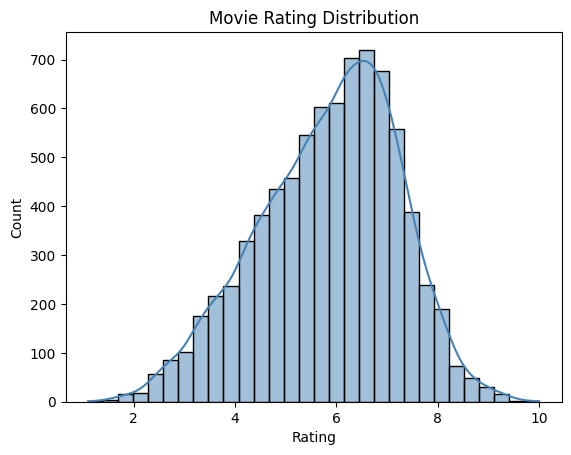

Average Rating: 5.84
Median Rating: 6.0


In [12]:
sns.histplot(df['Rating'], bins=30, kde=True, color='steelblue')
plt.title('Movie Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

print("Average Rating:", round(df['Rating'].mean(), 2))
print("Median Rating:", round(df['Rating'].median(), 2))

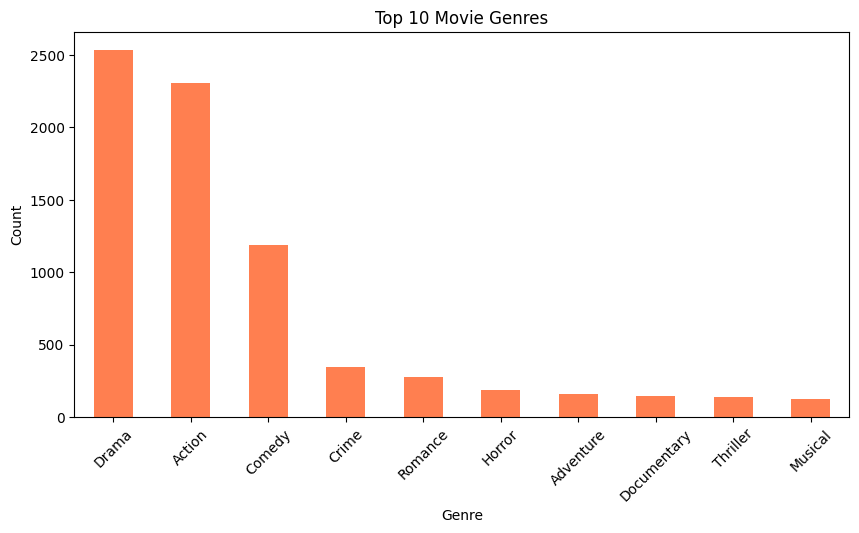

In [13]:
# Get first genre only
df['Main_Genre'] = df['Genre'].str.split(',').str[0].str.strip()

top_genres = df['Main_Genre'].value_counts().head(10)
top_genres.plot(kind='bar', color='coral', figsize=(10,5))
plt.title('Top 10 Movie Genres')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

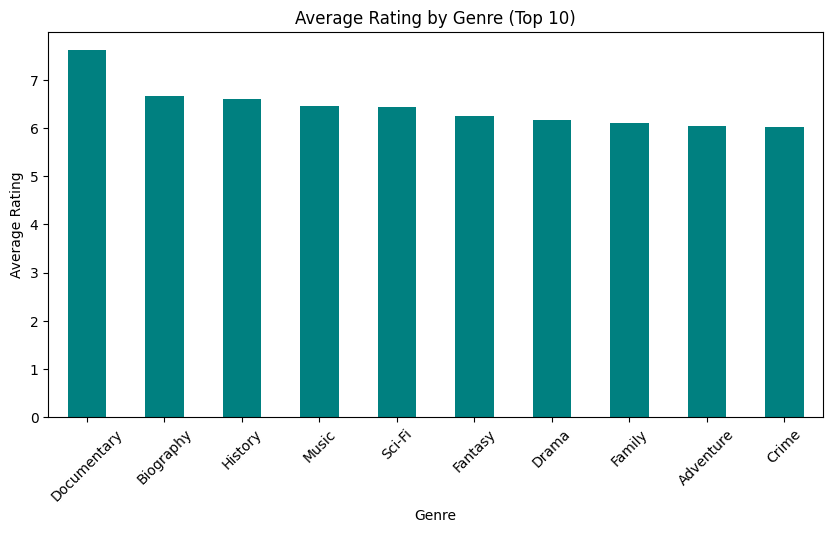

In [14]:
genre_rating = df.groupby('Main_Genre')['Rating'].mean().sort_values(ascending=False).head(10)
genre_rating.plot(kind='bar', color='teal', figsize=(10,5))
plt.title('Average Rating by Genre (Top 10)')
plt.xlabel('Genre')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)
plt.show()

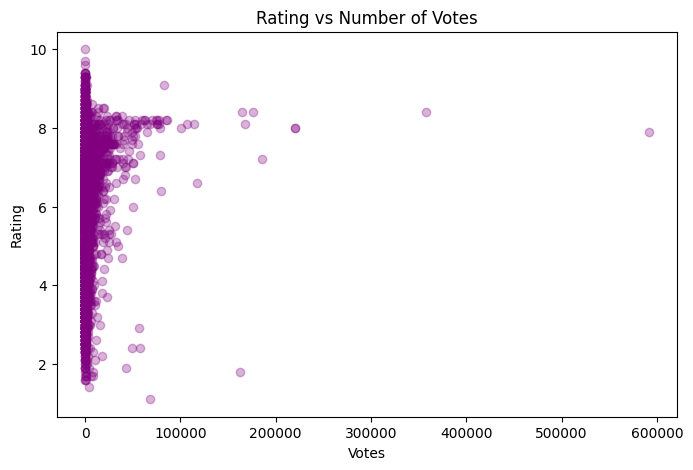

In [15]:
plt.figure(figsize=(8,5))
plt.scatter(df['Votes'], df['Rating'], alpha=0.3, color='purple')
plt.title('Rating vs Number of Votes')
plt.xlabel('Votes')
plt.ylabel('Rating')
plt.show()

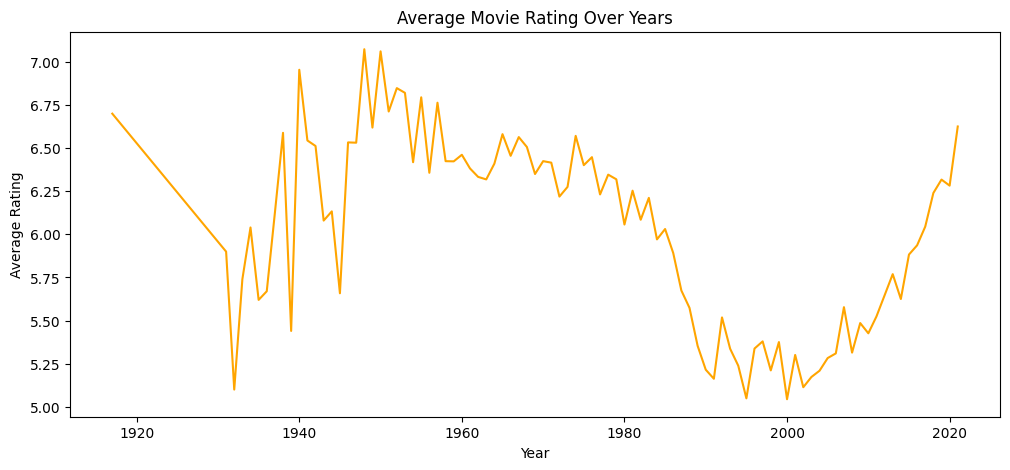

In [16]:
year_rating = df.groupby('Year')['Rating'].mean()
year_rating.plot(figsize=(12,5), color='orange')
plt.title('Average Movie Rating Over Years')
plt.xlabel('Year')
plt.ylabel('Average Rating')
plt.show()

In [17]:
le = LabelEncoder()

df['Genre_Encoded'] = le.fit_transform(df['Main_Genre'])
df['Director_Encoded'] = le.fit_transform(df['Director'])
df['Actor1_Encoded'] = le.fit_transform(df['Actor 1'])
df['Actor2_Encoded'] = le.fit_transform(df['Actor 2'])
df['Actor3_Encoded'] = le.fit_transform(df['Actor 3'])

print("Encoding done!")
df.head()

Encoding done!


,Name,Year,Duration,Genre,Rating,Votes,Director,Actor 1,Actor 2,Actor 3,Main_Genre,Genre_Encoded,Director_Encoded,Actor1_Encoded,Actor2_Encoded,Actor3_Encoded
1,#Gadhvi (He thought he was Gandhi),2019,109.0,Drama,7.0,8,Gaurav Bakshi,Rasika Dugal,Vivek Ghamande,Arvind Jangid,Drama,7,811,1782,2815,377
3,#Yaaram,2019,110.0,"Comedy, Romance",4.4,35,Ovais Khan,Prateik,Ishita Raj,Siddhant Kapoor,Comedy,4,1749,1589,890,2572
5,...Aur Pyaar Ho Gaya,1997,147.0,"Comedy, Drama, Musical",4.7,827,Rahul Rawail,Bobby Deol,Aishwarya Rai Bachchan,Shammi Kapoor,Comedy,4,2005,508,85,2449
6,...Yahaan,2005,142.0,"Drama, Romance, War",7.4,1086,Shoojit Sircar,Jimmy Sheirgill,Minissha Lamba,Yashpal Sharma,Drama,7,2643,931,1388,3030
8,?: A Question Mark,2012,82.0,"Horror, Mystery, Thriller",5.6,326,Allyson Patel,Yash Dave,Muntazir Ahmad,Kiran Bhatia,Horror,11,174,2521,1461,1205


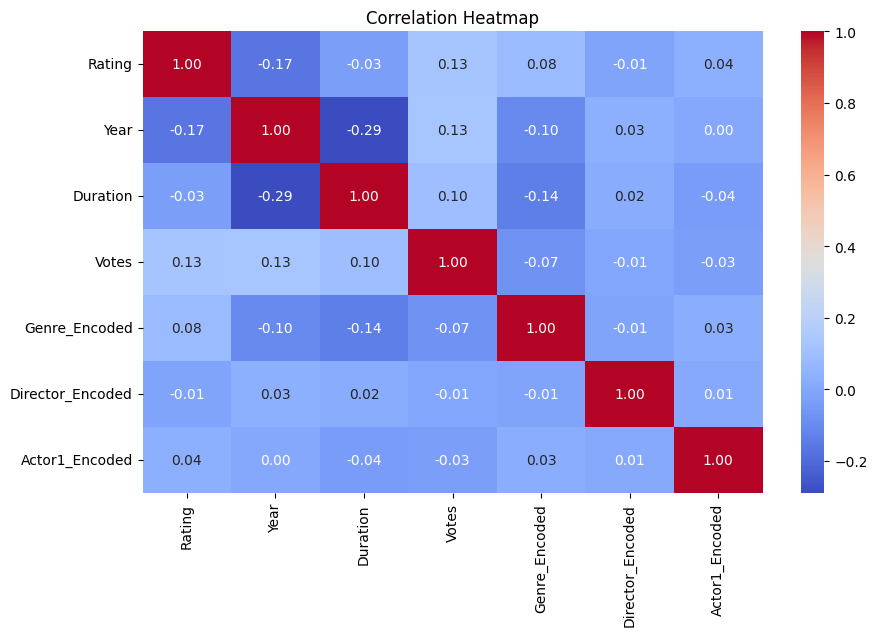

In [18]:
cols = ['Rating','Year','Duration','Votes',
        'Genre_Encoded','Director_Encoded','Actor1_Encoded']

plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [19]:
features = ['Year','Duration','Votes',
            'Genre_Encoded','Director_Encoded',
            'Actor1_Encoded','Actor2_Encoded','Actor3_Encoded']

X = df[features]
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (6335, 8)
Test size: (1584, 8)


In [20]:
lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

print("=== Linear Regression ===")
print("MAE:", round(mean_absolute_error(y_test, y_pred_lr), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_lr)), 3))
print("R2 Score:", round(r2_score(y_test, y_pred_lr), 3))

=== Linear Regression ===
MAE: 1.039
RMSE: 1.302
R2 Score: 0.089


In [21]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== Random Forest ===")
print("MAE:", round(mean_absolute_error(y_test, y_pred_rf), 3))
print("RMSE:", round(np.sqrt(mean_squared_error(y_test, y_pred_rf)), 3))
print("R2 Score:", round(r2_score(y_test, y_pred_rf), 3))

=== Random Forest ===
MAE: 0.836
RMSE: 1.109
R2 Score: 0.338


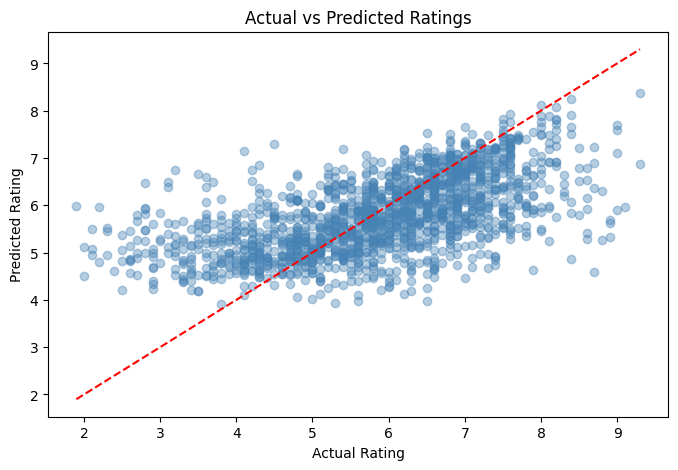

In [22]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred_rf, alpha=0.4, color='steelblue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--')
plt.title('Actual vs Predicted Ratings')
plt.xlabel('Actual Rating')
plt.ylabel('Predicted Rating')
plt.show()

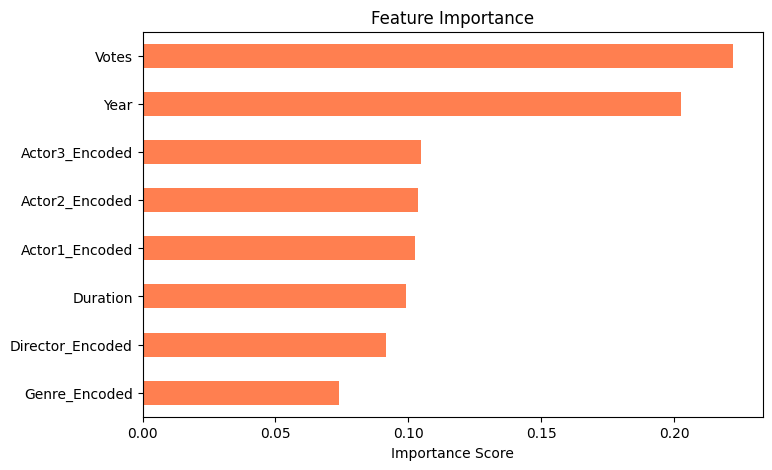

In [23]:
feat_imp = pd.Series(rf.feature_importances_, index=features)
feat_imp.sort_values().plot(kind='barh', color='coral', figsize=(8,5))
plt.title('Feature Importance')
plt.xlabel('Importance Score')
plt.show()

In [24]:
# Example: Predict rating for a new movie
new_movie = pd.DataFrame({
    'Year': [2023],
    'Duration': [120],
    'Votes': [5000],
    'Genre_Encoded': [3],
    'Director_Encoded': [10],
    'Actor1_Encoded': [25],
    'Actor2_Encoded': [40],
    'Actor3_Encoded': [15]
})

predicted_rating = rf.predict(new_movie)
print("Predicted Rating:", round(predicted_rating[0], 1))

Predicted Rating: 5.6


## Conclusion

- **Dataset:** IMDb India Movies dataset
- **Models Used:** Linear Regression & Random Forest Regressor
- **Best Model:** Random Forest

### Key Findings:
- **Votes** is the strongest predictor of rating
- **Director** and **Actors** significantly influence ratings
- **Genre** affects ratings — certain genres rate consistently higher
- **Duration** has mild correlation with rating

### Model Performance:
- Random Forest outperformed Linear Regression
- R2 Score shows the model explains variance in ratings well